# Elementary Stochastic Calculus

The focus is the machinery needed later for option pricing: Markov processes, martingales, Brownian motion, quadratic variation, stochastic integrals, stochastic differential equations, and Ito's lemma.

The code examples are synthetic and deliberately small. Most of the substance is in the equations and interpretation.

In [1]:
from random_asset_tools.stochastic_calculus import (
    TRADING_DAYS,
    build_sde_examples,
    create_rng,
    ito_square_identity,
    log_gbm_ito_check,
    plot_paths,
    plot_quadratic_variation,
    plot_quadratic_variation_convergence,
    plot_sde_examples,
    plot_stochastic_integral_identity,
    quadratic_variation,
    quadratic_variation_convergence,
    simulate_brownian_motion_with_drift,
    simulate_brownian_paths,
    simulate_geometric_brownian_motion,
    simulate_random_walk,
)

RNG = create_rng(seed=404)

## 1. The Point of Stochastic Calculus

Ordinary calculus says that if $F$ is a function of a variable $X$, then:

$$
dF = F'(X)\,dX.
$$

That rule relies on $X$ changing smoothly enough for ordinary derivatives to make sense. A Brownian path is continuous, but it is so jagged that it is not differentiable. Informally, $dX$ is of size $\sqrt{dt}$, so $dX/dt$ behaves like $1/\sqrt{dt}$ and blows up as $dt \to 0$.

Stochastic calculus is the replacement rulebook for functions of random variables whose changes include Brownian noise.

## 2. Expectation Notation

The notes start with the basic expectation calculation. If a random variable can take states $S_j$ with probabilities $P_j$, then the mean is:

$$
\mathbb{E}[S] = \sum_j P_j S_j.
$$

For a function of the random variable, such as an option payoff $F(S)$, the expected value is:

$$
\mathbb{E}[F(S)] = \sum_j P_j F(S_j).
$$

This is the bridge into derivatives: if the distribution of the future stock price is known, an expected payoff can be calculated from the same probability weights.

## 3. Markov Property

A process has the **Markov property** when the current state contains the information needed for the future distribution. The future can depend on where the process is now, but not on the route it took to get there.

In notation, this says the conditional law of the future is determined by the present state:

$$
\mathbb{P}(S_{t+\Delta t} \in A \mid S_t, S_{t-1}, S_{t-2}, \ldots)
= \mathbb{P}(S_{t+\Delta t} \in A \mid S_t).
$$

For option pricing this is powerful: under a Markov stock model, the option value can be written as a function of the current stock price and time, $V(S,t)$, rather than the whole past history.

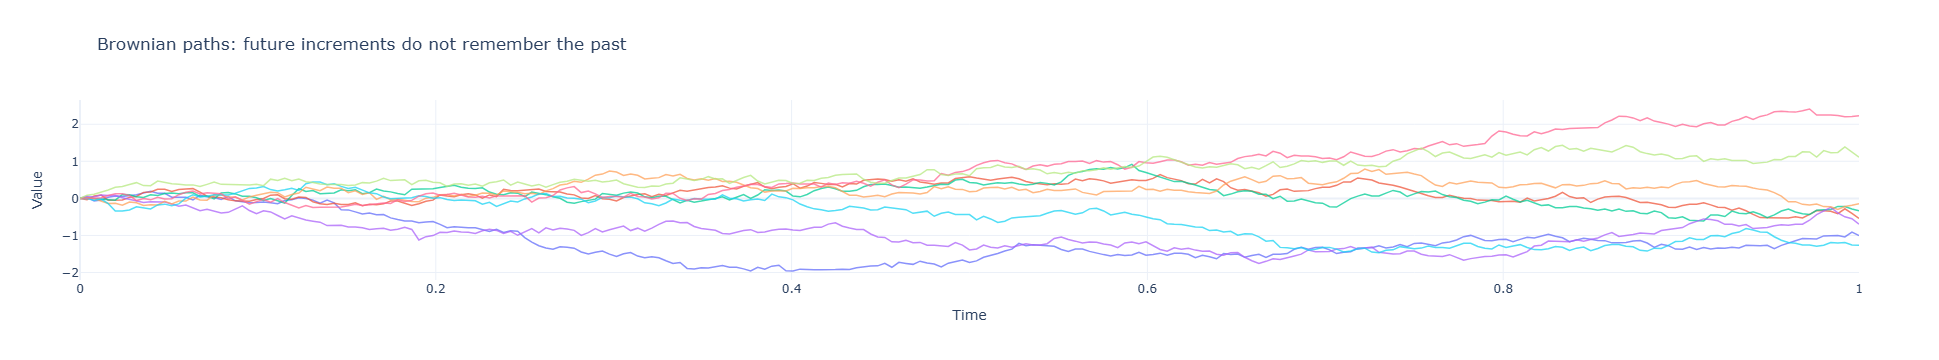

In [2]:
brownian_paths = simulate_brownian_paths(
    years=1.0,
    steps_per_year=TRADING_DAYS,
    path_count=8,
    rng=RNG,
)

plot_paths(brownian_paths, title="Brownian paths: future increments do not remember the past")

## 4. Martingale Property

A martingale is the mathematical version of a fair game. Given the information available now, the expected future value is the value you already have:

$$
\mathbb{E}[S_T \mid \mathcal{F}_t] = S_t, \qquad T \geq t.
$$

This does not mean the path is constant. The next movement can be up or down. It means there is no predictable drift once we condition on the current information.

Brownian motion is the standard example: its increments have mean zero and are independent of the past.

## 5. Brownian Motion from a Scaled Random Walk

The notes build Brownian motion from a coin-toss random walk. Over a time interval of length $t$, split time into $n$ pieces:

$$
t_i = \frac{i}{n}t, \qquad i=0,1,\ldots,n.
$$

At each step, move up or down by a size proportional to $\sqrt{t/n}$. Then:

$$
X(t_i)-X(t_{i-1}) \sim N\left(0,\frac{t}{n}\right)
$$

in the limiting Normal model. The key fact is not the direction of a single step, but the scaling: random movement over $dt$ has standard deviation $\sqrt{dt}$.

In [3]:
random_walk = simulate_random_walk(
    years=1.0,
    steps_per_year=64,
    path_count=8,
    rng=create_rng(seed=405),
)

plot_paths(random_walk, title="Scaled coin-toss random walk")

## 6. Variation and Quadratic Variation

For a path observed at times $0=t_0<t_1<\cdots<t_n=t$, ordinary variation adds absolute movement:

$$
\sum_{j=1}^n |S_j-S_{j-1}|.
$$

For Brownian paths this grows without bound as the partition gets finer. The curve is continuous, but its total path length is effectively infinite.

Quadratic variation instead adds squared movement:

$$
\sum_{j=1}^n (S_j-S_{j-1})^2.
$$

For Brownian motion this does not blow up. It converges to elapsed time:

$$
\sum_{j=1}^n (X_j-X_{j-1})^2 \to t.
$$

In [4]:
qv_paths = quadratic_variation(brownian_paths)
plot_quadratic_variation(qv_paths)

## 7. Why the Square Survives

The informal rule in the notes is:

$$
dX^2 = dt.
$$

More carefully, Brownian increments satisfy:

$$
dX \text{ is of size } \sqrt{dt},
\qquad (dX)^2 \text{ is of size } dt.
$$

This is the whole reason stochastic calculus differs from ordinary calculus. Terms that look second order in $dX$ are actually first order in time and cannot be ignored.

In [5]:
qv_convergence = quadratic_variation_convergence(
    years=1.0,
    step_counts=[16, 32, 64, 128, 252, 512, 1024],
    path_count=400,
    seed=409,
)

plot_quadratic_variation_convergence(qv_convergence)

## 8. Stochastic Integrals

A stochastic integral is the limit of sums like:

$$
\sum_j f(t_j)\left(X(t_{j+1})-X(t_j)\right).
$$

The important detail in the notes is timing. In the Ito convention, the value $f(t_j)$ is chosen before the random increment occurs. You do not get to wait for the stock move and then choose the hedge.

That is why the shorthand

$$
dW = f(t)\,dX
$$

must be read carefully: $f(t)$ is known at time $t$, while $dX$ is the random movement that happens just after $t$.

In [6]:
identity = ito_square_identity(brownian_paths[["Path 1"]])
plot_stochastic_integral_identity(identity)

## 9. Mean-Square Limit

The notes use the mean-square limit because stochastic quantities do not usually converge path-by-path in the ordinary deterministic sense.

A sequence of approximations $Y_n$ converges to $Y$ in mean square when:

$$
\mathbb{E}\left[(Y_n-Y)^2\right] \to 0.
$$

This says the average squared error disappears. It is the right kind of convergence for stochastic integrals and Brownian approximations.

In [7]:
qv_summary = quadratic_variation(
    simulate_brownian_paths(
        years=1.0,
        steps_per_year=TRADING_DAYS,
        path_count=500,
        rng=create_rng(seed=407),
    )
).iloc[-1]

qv_summary.describe().to_frame(name="Quadratic variation at t=1")

,Quadratic variation at t=1
count,500.000000
mean,1.004986
std,0.087748
min,0.761183
25%,0.946199
50%,0.998668
75%,1.061833
max,1.307863


## 10. Stochastic Differential Equations

A stochastic differential equation separates deterministic drift from random diffusion:

$$
dS = a(S,t)\,dt + b(S,t)\,dX.
$$

The drift term $a(S,t)dt$ controls the local mean movement. The diffusion term $b(S,t)dX$ controls the random part.

For the standard stock-price model:

$$
dS = \mu S\,dt + \sigma S\,dX.
$$

Here $\mu Sdt$ is the deterministic drift and $\sigma SdX$ is the random stock movement.

In [8]:
drift_paths = simulate_brownian_motion_with_drift(
    initial_value=0.0,
    drift=0.20,
    volatility=0.55,
    years=1.0,
    steps_per_year=TRADING_DAYS,
    path_count=8,
    rng=create_rng(seed=406),
)

plot_paths(drift_paths, title="Arithmetic Brownian motion: drift plus random shocks")

## 11. Ito's Lemma: Main Result

For an ordinary differentiable variable, $dF=F'(X)dX$. For a stochastic variable driven by Brownian motion, the extra quadratic-variation term must be kept:

$$
dF = F'(X)\,dX + \frac{1}{2}F''(X)\,dt.
$$

Example with $F(X)=X^2$:

$$
F'(X)=2X, \qquad F''(X)=2.
$$

Ordinary calculus would suggest:

$$
dF = 2X\,dX.
$$

Ito's lemma gives:

$$
dF = 2X\,dX + dt.
$$

That small-looking $dt$ term is not optional. It is the accumulated effect of Brownian quadratic variation.

In [9]:
identity.iloc[[0, 63, 126, 189, 252]]

,Path 1 X squared,Path 1 two integral plus time,Path 1 error
0.00,0.000000,0.000000,0.000000
0.25,1.115840,1.125640,-0.009800
0.50,2.980016,2.992266,-0.012250
0.75,1.477872,1.508513,-0.030640
1.00,1.000544,1.092558,-0.092014


## 12. Ito and Taylor

The notes compare Ito's lemma with a Taylor expansion. For a smooth function of $X$ and $t$:

$$
dF = F_t\,dt + F_X\,dX + \frac{1}{2}F_{XX}(dX)^2
      + F_{Xt}\,dX\,dt + \frac{1}{2}F_{tt}(dt)^2 + \cdots
$$

Then use the Brownian order rules:

$$
(dX)^2 = dt, \qquad dX\,dt = 0, \qquad (dt)^2=0.
$$

This leaves:

$$
dF = F_t\,dt + F_X\,dX + \frac{1}{2}F_{XX}\,dt.
$$

The intuition is that the second derivative survives because Brownian paths are rough enough for squared increments to add up.

## 13. Option Value Version of Ito's Lemma

In finance, the key function is the option value:

$$
V = V(S,t).
$$

If the stock follows:

$$
dS = \mu S\,dt + \sigma S\,dX,
$$

then Ito's lemma gives:

$$
dV = \frac{\partial V}{\partial t}dt
   + \frac{\partial V}{\partial S}dS
   + \frac{1}{2}\sigma^2S^2\frac{\partial^2 V}{\partial S^2}dt.
$$

The term $\partial V/\partial S$ is delta. The second derivative term is the gamma contribution created by random stock-price movement.

In [10]:
gbm_paths = simulate_geometric_brownian_motion(
    initial_price=100.0,
    drift=0.08,
    volatility=0.30,
    years=2.0,
    steps_per_year=TRADING_DAYS,
    path_count=20,
    rng=create_rng(seed=408),
)

plot_paths(gbm_paths, title="Lognormal asset paths from dS = mu S dt + sigma S dX")

## 14. Ito and the Lognormal Correction

A stock model may have drift $\mu$ in $S$, but the logarithm has a different drift. Applying Ito's lemma to $F(S)=\log(S)$ gives:

$$
d\log(S) = \left(\mu - \frac{1}{2}\sigma^2\right)dt + \sigma\,dX.
$$

The correction $-\frac{1}{2}\sigma^2$ comes from the second derivative of the log function. This is why a geometric Brownian motion gives lognormal prices.

In [11]:
log_check = log_gbm_ito_check(gbm_paths, drift=0.08, volatility=0.30)
log_check.iloc[[0, 126, 252, 378, 504]]

,Mean log return,Ito expected log return,Mean price,Expected price
0.0,0.000000,0.0000,100.000000,100.000000
0.5,0.036076,0.0175,106.116356,104.081077
1.0,0.035141,0.0350,109.450007,108.328707
1.5,0.124529,0.0525,125.074778,112.749685
2.0,0.181632,0.0700,127.553695,117.351087


## 15. Higher-Dimensional Ito

With several stochastic variables, Ito's lemma also keeps cross terms. If the Brownian shocks are correlated, then:

$$
dX_1\,dX_2 = \rho\,dt.
$$

For two state variables, second derivatives such as $V_{S_1S_1}$, $V_{S_2S_2}$, and $V_{S_1S_2}$ can all matter.

This is the multi-asset version of the same rule: Brownian products are not automatically negligible.

## 16. Pertinent Examples

The notes finish by listing common stochastic processes.

Brownian motion with drift:

$$
dS = \mu\,dt + \sigma\,dX.
$$

Lognormal random walk:

$$
dS = \mu S\,dt + \sigma S\,dX.
$$

Ornstein-Uhlenbeck mean reversion:

$$
dS = \lambda(m-S)\,dt + \sigma\,dX.
$$

Square-root mean reversion:

$$
dr = \lambda(m-r)\,dt + \sigma\sqrt{r}\,dX.
$$

The square-root term reduces volatility near zero, which helps keep the process from wandering into negative values.

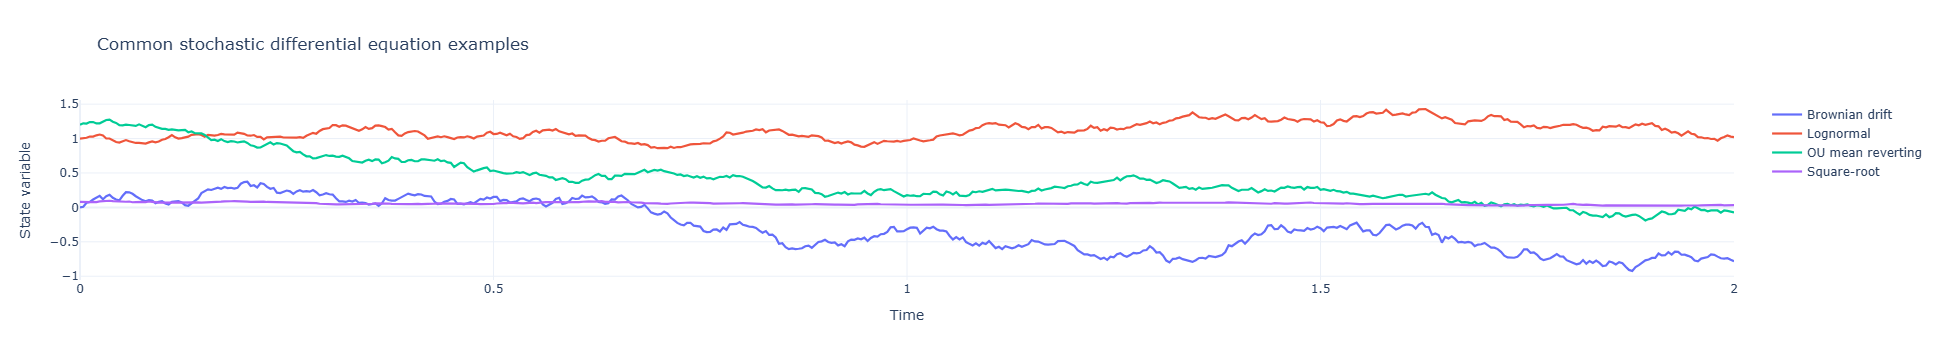

In [12]:
sde_examples = build_sde_examples(seed=606)
plot_sde_examples(sde_examples)

## Key Takeaways

- A stochastic process can be continuous without being differentiable.
- Brownian movement over $dt$ is of size $\sqrt{dt}$.
- Brownian quadratic variation is finite and equals elapsed time.
- The informal rules are $(dX)^2=dt$, $dX\,dt=0$, and $(dt)^2=0$.
- Stochastic integrals use information available before the random movement.
- Ito's lemma is Taylor's expansion plus the Brownian quadratic-variation rule.
- For $V(S,t)$, Ito's lemma creates the delta, gamma, and theta terms needed for option pricing.
- Lognormal stock prices require the $-\frac{1}{2}\sigma^2$ correction in log space.
- Mean-reverting and square-root models modify the drift and diffusion terms to match different financial quantities.